## Surrogate Modeling on TACC Systems: Epidemic Simulation

Surrogate modeling is an engineering technique in which the evaluation of a complex system is replaced by the evaluation of a simpler one. One discovers the simpler system through data: with machine learning, one can identify coordinates in which the system dynamics evolve on a low-dimensional manifold. The resulting model is fast to evaluate, often 1 to 3 orders of magnitude faster than the original system, but with the limiation that predictions are only valid within a range determined by the training data. One can think of surrogate modeling as a sophsticated form of interpolation.

This tutorial walks through the process of surrogate modeling for a representative dynamical system: disease spread in the epidemic regime. Disease spread describes the process by which infectous pathogens are transmitted across a population in time and space. The dynamics of disease spread are multi-scale, chaotic, and highly uncertain, mandating a computational framework that can capture these various effects. 

To predict the spread of disease forward in time, computational scientist rely on idealized **compartment** models, in which individuals are partitioned into a finite number of compartments based on their current infection status. In this tutorial, we consider the SEIR compartment model, in which individuals are classified as susceptible (S), exposed (E), infected (I), or recovered (R). In its **deterministic** formulation, the SEIR compartment model evolves forward in time according to the following set of ODE's:

$$
\frac{dS}{dt} = -\frac{\beta I}{N} S
$$
$$
\frac{dE}{dt} = \frac{\beta I}{N} S - \sigma E
$$
$$
\frac{dI}{dt} = -\sigma E - \gamma I
$$
$$
\frac{dR}{dt} = \gamma I
$$

In the equation above $N$ is the total population, while [$\beta$, $\sigma$, and $\gamma$] are a set of numerical constants tuned to the regime of interest. The intial condition consists of a state vector, [$S_0$, $E_0$, $I_0$, $R_0$], where $E_0$ is seeded to some non-zero initial exposure. Note that these equations are often augmented to account for a variety of auxillarly effects, including migration between counties, age-dependent vulnerabilities, and vaccination rates. 

The SEIR equations happen to be a very good candidate for surrogate modeling. While the complete equations contain a spectrum of dynamics, decision-makers are often interested in a single regime, simulating a large number of similar scenarios related to a specific pathogen. Traditional numerical integration techniques are costly in this context, particularly when modeling populations with a large number of nodes/counties, and potentially redundant, given that each scenario is quite similar. 

For this tutorial, we build a surrogate model for the simulation of disease spread in Washington, DC. Our dataset consists of 40 separate similations, each corresponding to a different initial exposure and/or rate of infection, and tracks the four SEIR compartments over a period of 500 days. We partition the modeling process into the following key steps:

1. Data Loading and Normalization
2. Establishing a Network Architecture and Learning Objective
3. Model Training
4. Model Evaluation
5. Ablation Studies

Note that our dataset is simplified compared to a production simulation suite, but is still complex enough to illustrate several interesting aspects of the surrogate modeling pipeline. The goal of this tutorial is not to build a production model, but rather to give the reader an entry point into surrogate modeling on TACC systems. Let's get started!

In [1]:
# Import base python libraries
import functools
import os
import glob
import time
import json
from IPython.display import clear_output, display

# Import array-handling libraries
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

# Import Pytorch for neural network training
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.utils.parametrizations as param

# Import sklearn libraries for convenient data segmentation
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Define device and 
print('Checking for GPU...')
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Checking for GPU...
Using device: cuda


### Part 1: Data Loading and Normalization

We begin by loading a dataset of simulation outputs, which were completed prior to this tutorial. In total, we ran 40 simulations, configuring the simulations to mimic the conditions of disease spread in Washington DC. The district's low total population (compared to a large population like Texas) makes the modeling problem tractable for this simple tutorial.  The input to each simulation consists of two values: an initial exposure $E_0$ and an infection rate constant $R_0$. The output contains the SEIR state vector recorded at 500 forward time steps. The following cells loads our pre-configured dataset, extracts its shape, and move the data to the GPU for processing:

In [2]:
# Load mean dataset
data = np.load('/scratch/projects/tacc/sci-training/TACCSTER2026/data/district_of_columbia_dataset.npz')
data_in = data['data_in']
data_out = data['data_out']

# Extract relevant constants
num_cases, num_timesteps, num_features = np.shape(data_out)

# Convert to pytorch tensor
data_in = torch.tensor(data_in,dtype=torch.float32)
data_out = torch.tensor(data_out,dtype=torch.float32)

# Move to GPU
data_in = data_in.to(device)
data_out = data_out.to(device)

# Display shapes of the input and output data
print('Shape of input data:')
print(data_in.shape)
print('Shape of output data:')
print(data_out.shape)

Shape of input data:
torch.Size([40, 2])
Shape of output data:
torch.Size([40, 500, 4])


Note that it's very important to keep track of the dataset size, and what each dimension corresponds to! For the input data, the first dimension corresponds to the simulation ID, while the second dimension contains our two input parameters. For the output data, the first dimension again corresponds to the simulation ID, the second dimension corresponds to timestep ID, and the third dimension contains the SEIR values.

Having loaded the data, our next step is to normalize it. Data normalization is an essential step in any machine learning application. By normalizing our data, we effectively separate data patterns from their scale, thus lowering the number of features that the network must learn and simplifying the optimization landscape. You can think of normalization as an attempt to make the problem as easy as possible for the machine to solve.

There are several options for normalization, including Z-score normalization (for data that resembles a Gaussian), min/max scaling (for data with few outliers), and log scaling (for highly skewed data) . The exact normalization scheme is generally chosen after examing the distribution of your specific dataset. For the spatiotemporal data often found in surrogate modeling, the main consideration is to ensure that your choice respects continuity across the relevant dimension. This means that the normalization scheme should be uniform across time and/or space.

In the following cells, we plot our complete dataset, as both a temporal evolution (top row) and as a frequency distribution (bottom row).

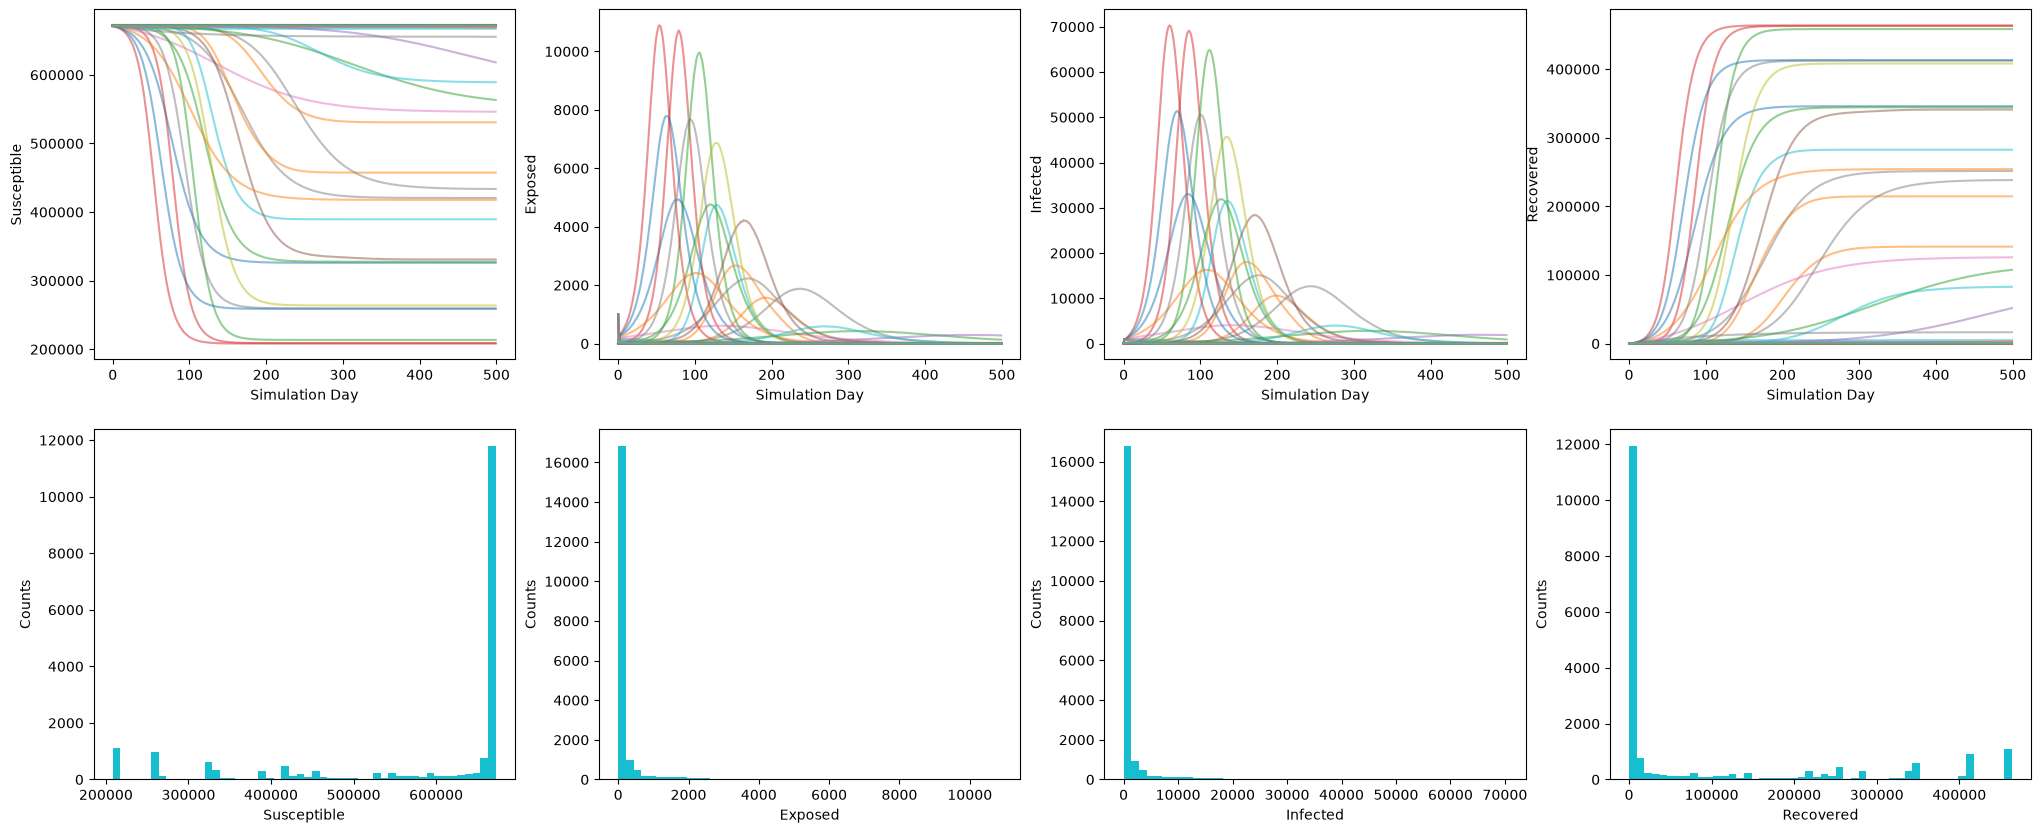

In [3]:
# Collapse data for plotting as a histogram
data_collapsed = data_out.reshape(-1, *data_out.shape[2:])
bins = 50

# Visualize data in feature vs. time space
plt.figure(figsize=(25,10))
for sim_ind in range(0,len(data_out)):
            plt.subplot(2,4,1)
            plt.plot(data_out[sim_ind,:,0].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Susceptible')
            plt.subplot(2,4,2)
            plt.plot(data_out[sim_ind,:,1].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Exposed')
            plt.subplot(2,4,3)
            plt.plot(data_out[sim_ind,:,2].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Infected')
            plt.subplot(2,4,4)
            plt.plot(data_out[sim_ind,:,3].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Recovered')
            plt.subplot(2,4,5)
            plt.hist(data_collapsed[...,0].cpu(), bins = bins)
            plt.xlabel('Susceptible')
            plt.ylabel('Counts')
            plt.subplot(2,4,6)
            plt.hist(data_collapsed[...,1].cpu(), bins = bins)
            plt.xlabel('Exposed')
            plt.ylabel('Counts')
            plt.subplot(2,4,7)
            plt.hist(data_collapsed[...,2].cpu(), bins = bins)
            plt.xlabel('Infected')
            plt.ylabel('Counts')
            plt.subplot(2,4,8)
            plt.hist(data_collapsed[...,3].cpu(), bins = bins)
            plt.xlabel('Recovered')
            plt.ylabel('Counts')

Here we see our first quirk of surrogate modeling with simulation data! Because the dataset evolves dynamically, it tends to cluster around attractors, or equilibrium states. In the case of our epidemic dataset, the zero solution (i.e, an epidemic does not occur) is an equilibrium state, and our data appears is heavily skewed toward the zero solution. The upshot is that we end up with a very "peaky" dataset, in which each peak corresponds to a recurring state of the system, that doesn't lend itself to an obvious normalization scheme. In situations like this, we default to a simple min/max scaling. 

Note that while our normalization scheme is simple, the distribution of our data is still very relevant to the design of our network. Later on in the tutorial, we will address our the "zero-inflation" observed above with a specific architectural choice.

In [4]:
# Normalize per feature
norm_factors = torch.zeros((num_features,2)).to(device)
for ind_features in range(0,num_features):
    norm_factors[ind_features,0] = torch.min(data_out[:,:,ind_features])
    norm_factors[ind_features,1] = torch.max(data_out[:,:,ind_features])-torch.min(data_out[:,:,ind_features])
    data_out[:,:,ind_features] = (data_out[:,:,ind_features]-norm_factors[ind_features,0])/norm_factors[ind_features,1]    

As a final step in our data preparation, we segment the data into a test/train split. Just like a typical machine learning pipeline, this step allows us to monitor for over-fitting during the evaluation step.

In [5]:
# Setup test/train split
test_size = 0.2
data_in_train, data_in_test, data_out_train, data_out_test = train_test_split(
	data_in, data_out, test_size=test_size, random_state=42
	)

# Display shapes of the input and output data
print('Shape of training data:')
print(data_in_train.shape)
print(data_out_train.shape)

print('Shape of test data:')
print(data_in_test.shape)
print(data_out_test.shape)


Shape of training data:
torch.Size([32, 2])
torch.Size([32, 500, 4])
Shape of test data:
torch.Size([8, 2])
torch.Size([8, 500, 4])


### Part 2: Establishing an Architecture and Objective

Having loaded and normalized our data, the next step in our pipeline is to select a neural network architecture. In the context of this tutorial, the term 'architecture' refers to the structural organization of a model's weights. That is, are all features linked to one another when making predictions, or are they grouped based on their index? Does the network predict one forward step at a time, or does it predict the entire solution trajectory? These decisions effectively determine the optimization space; tailoring the network architecture to a given dataset often makes the difference between a robust model and a model that is unable to learn anything about your data at all.

For dynamical modeling, in which the data has some continuous time dimension, neural network architectures generally fall into one of two categories: flow maps and trajectory maps. Flow maps take a classic dynamical approach and predict the evolution of the system one step at a time. This approach is well-suited to capturing fine-grained local dynamics but comes at the expense of long-horizon stability. In constrast, trajectory maps predict the evolution of the system all at once, starting from an initial condition and mapping to the complete solution. Trajectory maps remove the stability concerns that plague numerical integration techniques but quickly become intractable for high-dimensional problems. The common physics-informed neural networks (PINN), in which a network learns the solution operator of a PDE, is considered a variant of the trajectory map. 

<span style="color: red;">INSERT A GRAPHIC HERE SHOWING THE DIFFERENCE BETWEEN FLOW MAPS AND TRAJECTORY MAPS</span>

For this tutorial, we model the evolution of SEIR compartments with a **trajectory map** approach. The reason for this choice is derived from the dimensionality of our dataset: the state vector consists of only 4 features, making it feasible to predict several hundred timesteps forward at once. Note that for simulations with substantially larger populations, such as a simulation for Texas, the state vector is augmented with SEIR data for each county or sub-population. In this scenario, the dimensionality of the problem quickly becomes intractable, and one must turn to time-stepping flow maps to simplify the optimization landscape. Later in this tutorial, we will train a simple flow map on the Washington, DC dataset as a way of illustrating first hand the stability issues associated with these architectures. 

The following cell implements a trajectory map architecture in PyTorch's standard class format. We construct the network itself with a simple multi-layer perceptron (MLP); the dimensions of each layer are based on the dimensions of the state vector and the number of output timesteps. A few notes before we proceed:

- We design our network as an MLP, but any number of architectures could be substituted here. The choice ultimately depends on the shape of our input data. If our input data was a set of images, for example, we could take advantage of local spatial correlations with a 2D convolutional layer.  
- We introduce a slight quirk into the feedforward function: rather than mapping to the output directly, we map the input data to coefficients for a set of basis functions. This is an extra measure added to our network to ensure that output trajectories are smooth. Later on in the tutorial, we will show what happens when we remove the 
- We incorporate a sigmoid activation function to the final output to ensure that our predictions all lie within [0,1]. This a **hard architectural constraint** that matches our normalization strategy and is intended to speed up convergence. Production surrogate models often have several dataset-specific constraints baked into their architecture; if we wanted, we could add additional logic ensuring that certain columns are monotonic, certain columns add up to 1, or certain quantities are preserved exactly. The incorporation of architectural constraints is driven by design requirements and the model's baseline convergence rate. 

In [6]:
class EPI(torch.nn.Module):

    # Initialization
    def __init__(  
        self,
        basis,                     # Smoothing basis function
        num_input_parameters: int, # The number of features in our input tensor
        hidden_channels: int,      # The 'width' or 'capacity' of the network
        num_total_timesteps: int,  # The total number of timesteps in the output trajectory
        num_features: int,         # The number of features in our state vector
        n_epoch: int,              # Training parameter: number of iterations or epochs
        batch_size: int,           # Training parameter: the number of samples per batch
        learning_rate: float,      # Training parameter: the initial learning rate
        ):
        super().__init__()

        # The following lines are a PyTorch quirk, we store the input parameters as class constants so they 
        # can be called within the training method
        self.hidden_channels = hidden_channels
        self.num_total_timesteps = num_total_timesteps
        self.num_features = num_features
        self.activation = nn.ReLU()
        self.num_input_parameters = num_input_parameters
        self.basis = basis
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.n_epoch = n_epoch

        # Define each layer of the feedforward architecture
        self.layer1 = nn.Linear(self.num_input_parameters,self.hidden_channels)
        self.layer2 = nn.Linear(self.hidden_channels,self.hidden_channels)
        self.layer3 = nn.Linear(self.hidden_channels,self.hidden_channels)
        self.coeff_head = nn.Linear(self.hidden_channels,self.num_features*self.basis.shape[0])

    # Forward pass function
    def forward(self, xin, x0):

        # Extract current batch size
        batch_size = xin.shape[0]

        # Feedforward from the input
        x = self.layer1(xin)
        x = self.activation(x)
        x = self.layer2(x)
        x = self.activation(x)
        x = self.layer3(x)
        x = self.activation(x)
        A = self.coeff_head(x)

        # Map from basis coefficient space to output trajectory space
        A = A.reshape(batch_size,self.num_features,self.basis.shape[0])
        xout = torch.matmul(A,self.basis).permute(0, 2, 1)
        xout = x0 + xout    

        # Ensure outputs are within [0,1]
        xout = torch.sigmoid(xout)
        return xout                

The training objective is often chosen alongside the network's structural design. Much like conventional neural network training, candidate loss functions for surrogate modeling include the mean square error (for problems framed as regression), binary cross-entropy (for problems framed as classification), and negative log likelihood (for problems framed probabilistically). Given that our outputs are continuous in time, it is reasonable to frame our modeling problem as a regression. We choose the standard mean square error as our loss function, making use of PyTorch's bulit-in MSE module:

In [7]:
# Define loss function for EPI class
EPI.loss = nn.MSELoss()

Note that it is extremely common in surrogate modeling for constraints to be imposed on the network via extra terms in the loss function. Physics-informed neural networks, for example, often augment the loss function with terms that enforce mass or momentum conservation. These constraints are considered regularizers or, in the case of maximum likelihood estimation, knowledge priors. Note that unlike hard architectural constraints, objective-based constraints are not strictly enforced or guranteed. The loss will never reach exactly zero during training, and thus loss constraints can never be exact. For this reason, it is often recommended to incorporate design requirements as hard architectural constraints, while using an augmented loss function only as a way of "guiding" the optimization (or avoiding troublesome local minima).

### Part 3: Model Training

We are now ready to move into the most computationally intensive aspect of machine learning: model training. In the context of ML, model training describes the process of iteratively updating a model's weights, such that the direction/magnitude of each update is driven by the distance between predictions and ground truth data. Programmatically, model training consists of a few key steps: we start an iteration, predict the output for each sample (in batches), compute a loss for each sample, and backpropagate that loss through the neural network. This basic loop is often augmented with measures for speeding up convergence, such as shuffling the data at each iteration or dynamically adjusting the model's learning rate, but it's essential structure remains the same. The following cell implements a basic training loop in PyTorch, with comments noting the relevance of each code block:

In [8]:
# Define training loop as a function
def train(self, data_in, data_out, data_in_test, data_out_test):

        # Select an optimizer (Adam is a good starting point for most surrogate optimization tasks) and add the relevant
        # model parameters
        print('Setting up optimizer...')
        optimizer = optim.Adam([
            {'params': self.layer1.parameters()},
            {'params': self.layer2.parameters()},
            {'params': self.layer3.parameters()},
            {'params': self.coeff_head.parameters()},
            ],lr = self.learning_rate)

        # Initialize loss tracking. Note that we also store the prediction for a "base case" at each epoch so we can 
        # visualize the machine's optimization route later on.
        loss_list_train = []
        loss_list_test = []
        self.base_case_in = data_in[20]
        self.base_case_out = data_out[20]
        self.base_case_pred = [] 

        # Begin iterating through epochs
        print('Starting training...')
        for it in range(0, self.n_epoch):

            # Shuffle the data
            ind_shuffle = torch.randperm(data_in.size()[0])
            data_in = data_in[ind_shuffle]
            data_out = data_out[ind_shuffle]

            # Loop through batches
            loss_track = 0.0
            for ind in range(0,data_in.size()[0],self.batch_size):
                loss = 0.0
                optimizer.zero_grad()
                ind_batch = range(ind,ind+self.batch_size)
                if ind+self.batch_size > data_in.size()[0]:
                    ind_batch = range(ind,data_in.size()[0])

                # Compute predictions for each sample    
                data_pred = self(data_in[ind_batch],data_out[ind_batch,0,:].unsqueeze(1))

                # Compute loss for each sample
                loss = self.loss(data_pred,data_out[ind_batch]) 

                # Backprogate and update the network weights
                loss.backward()
                optimizer.step()
                loss_track += float(loss.item())
                
            # Compute test data loss (for monitoring overfitting)
            data_pred_test = self(data_in_test,data_out_test[:,0,:].unsqueeze(1))
            loss_test = self.loss(data_pred_test,data_out_test).item()
            loss_list_train.append(loss_track) 
            loss_list_test.append(loss_test)
            self.base_case_pred.append(self(self.base_case_in.unsqueeze(0),self.base_case_out[0,:].unsqueeze(0).unsqueeze(0)))

            # Display train + test loss at regular increments
            if it == 0 or (it+1)%1000==0:
                print('Epoch: ' + str(it) + '  |  ' + 'Train Loss: ' + str(loss_track) + '  |  ' + 'Test Loss: ' + str(loss_test))

        # Store the test + train loss as a model parameter
        self.loss_list_train = loss_list_train
        self.loss_list_test = loss_list_test

# Add the training function as a model method
EPI.train = train

Having created the training method, we now have all the architectural tools in place to train our network. Our final step is to instantiate a model object and select a few training hyperparameters, including the batch size, number of epochs, and learning rate. The following list provides typical ranges for each of these hyperparameters in the context of surrogate model training. It is recommended that one begins with parameters in this range before tuning them to match your specific dataset.

- batch_size: $16$ -- $128$
- hidden_channels: $16$ -- $128$
- n_epoch: $10^2$ -- $10^4$
- learning_rate: $10^{-4}$ -- $10^{-3}$

In [9]:
# Extract tailored basis from PCA
numPCA = int(5)
pca = PCA(n_components=numPCA, svd_solver='auto')
X = np.permute_dims(data_out.cpu(), axes=(0,2,1))
X = X.reshape(-1, *X.shape[2:])
pca.fit(X)
basis = pca.components_[0:numPCA]
basis = torch.tensor(basis,dtype=torch.float32)
basis = basis.to(device)

# Set the random seed for model initialization (optional, only included so this notebook outputs consistent results :)
torch.manual_seed(16)

# Initialize model architecture
print('Initializing model...')
epi = EPI(
	hidden_channels=32,
	n_epoch= 10000,
	batch_size=32,
	learning_rate = 5e-4,
	num_total_timesteps=500,
	num_features = 4,
    num_input_parameters = 2,
	basis = basis
	)
epi = epi.to(device)
print('Model initialized!')

Initializing model...
Model initialized!


Note that in the cell above, we perform principal component analysis (PCA) to derive a basis function, and we include that basis as an input to the model object. Again, this is not strictly necessary and is included as a means to smooth the model's predictions over the time dimension. In part 5 of this notebook, we will more precisely pinpoint the influence that this PCA basis imposes on the model's predictions.

With our architecture, objective, training loop, and hyperparameters in place, we are at last ready to train the model. Let's get ready to watch a few numbers slowly get smaller! 

In [10]:
# Train model
epi.train(data_in_train,data_out_train,data_in_test,data_out_test)

Setting up optimizer...
Starting training...
Epoch: 0  |  Train Loss: 0.1861594170331955  |  Test Loss: 0.20224906504154205
Epoch: 999  |  Train Loss: 0.04631474241614342  |  Test Loss: 0.08083812147378922
Epoch: 1999  |  Train Loss: 0.013445183634757996  |  Test Loss: 0.02114707976579666
Epoch: 2999  |  Train Loss: 0.007563900202512741  |  Test Loss: 0.008237414993345737
Epoch: 3999  |  Train Loss: 0.00337455072440207  |  Test Loss: 0.0050857216119766235
Epoch: 4999  |  Train Loss: 0.0021845244336873293  |  Test Loss: 0.00447113998234272
Epoch: 5999  |  Train Loss: 0.0018128161318600178  |  Test Loss: 0.003969267942011356
Epoch: 6999  |  Train Loss: 0.0013112311717122793  |  Test Loss: 0.003693401115015149
Epoch: 7999  |  Train Loss: 0.0011429896112531424  |  Test Loss: 0.003626270452514291
Epoch: 8999  |  Train Loss: 0.0008990210480988026  |  Test Loss: 0.0032936197239905596
Epoch: 9999  |  Train Loss: 0.0007217110833153129  |  Test Loss: 0.0025782587472349405


Looking at numerical values of the loss, this is a very nice result! The training loss steadily decreased over each epoch, implying that the model is learning *something* about the data . What's more, the test loss (i.e., data that the model is not explicitly trained upon) decreases steadily as well, implying that the model avoided over-fitting and has learned something generalizable. In the next section, we will see exactly what the model has and has not learned by comparing its output to the ground truth dataset. 

### Part 4: Model Evaluation

Machine learning models can rarely be optimized to the point of zero loss (i.e., an exact replication of the trianing data), so it is very important to verify that the model has learned features relevant to your design goals, not just that the loss has decreased steadily. This extra verification step often takes the form of by data visualization. 

In the cell that follows, we generate a series of plots that visualize the learning process as a function of epoch. On the left hand side, we show the loss function as it decreases over successive epochs. On the right hand side, we show a representative sample from the training data set and monitor how the model's prediction evolves throughout the training loop. Note that all of the data needed to generate these plots was stored as part of the `epi` model object while running the training loop in the previous section.

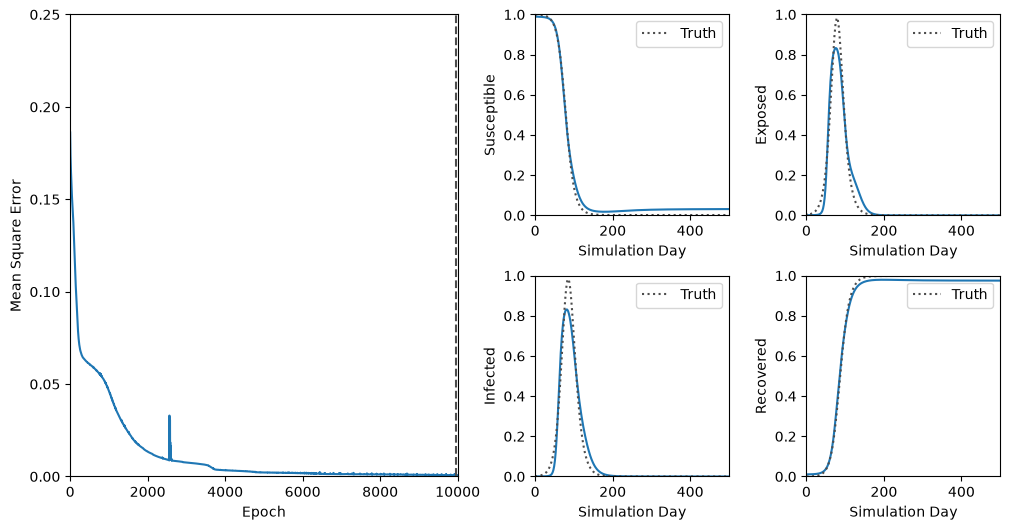

In [11]:
# Move relevant tensors to cpu for plotting
pred = torch.stack(epi.base_case_pred,dim=0).cpu().detach().numpy().squeeze()
truth = epi.base_case_out.cpu().detach().numpy()

# Define plot layout
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 3, width_ratios=[2, 1, 1], height_ratios=[1, 1], wspace=0.3, hspace=0.3)

# Initialize subplot
ax_big = fig.add_subplot(gs[:, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

# Plot the loss curve and a representative output
feature_names = ['Susceptible','Exposed','Infected','Recovered']
display(fig, display_id="training_plot")
for ind in range(0,epi.n_epoch,50):
    ax_big.clear()
    ax_big.plot(np.array(epi.loss_list_train))
    ax_big.plot([ind,ind],[-1,1],'--',color=[0.3,0.3,0.3])
    ax_big.set_xlim(0,epi.n_epoch)
    ax_big.set_ylim(0,0.25)
    ax_big.set_xlabel('Epoch')
    ax_big.set_ylabel('Mean Square Error')
    
    for ind_features, ax in enumerate([ax1,ax2,ax3,ax4]):
        ax.clear()
        ax.plot(pred[ind,:,ind_features])
        ax.plot(truth[:,ind_features],':',color=[0.3,0.3,0.3],label='Truth')
        ax.set_xlim(0,500)
        ax.set_ylim(0,1)
        ax.set_xlabel('Simulation Day')
        ax.set_ylabel(feature_names[ind_features])
        ax.legend()

    display(fig,display_id="training_plot",update=True)
    time.sleep(0.01)
plt.close(fig)    

We see that the learning process, while reasonably smooth with respect to epoch, is highly nonlinear. The model does not learn the evolution of each compartment uniformly; the accuracy of the susceptible compartment, for example, will sometimes improve at the expense of the infected compartment. This figure provides a nice way of thinking about the optimization process: the model is searching through candidate functions that match our architecture constraints, and its journey may include some diversions. By carefully choosing an architecture, objective, and normalization, our role is to prevent the model from wandering too far.

By the final epoch, the model's predictions appear very close to the ground truth data, missing only the peak values of the exposed and infected compartments. Keep in mind, however, that this baseline sample was taken from our training set. The model has 'seen' this sample thousands of times as part of the training process, so we expect the accuracy of its predictions to be quite good. The real question is whether the model can accurately predict cases it has never seen before, which is how the model would be deployed in practice.

The following cell plots model predictions for the *test* portion of our dataset. Recall that the test set includes samples withheld from the loss computation at each epoch. Assessing the model's performance on the test dataset is thus comparable to assessing the model's generalizability.

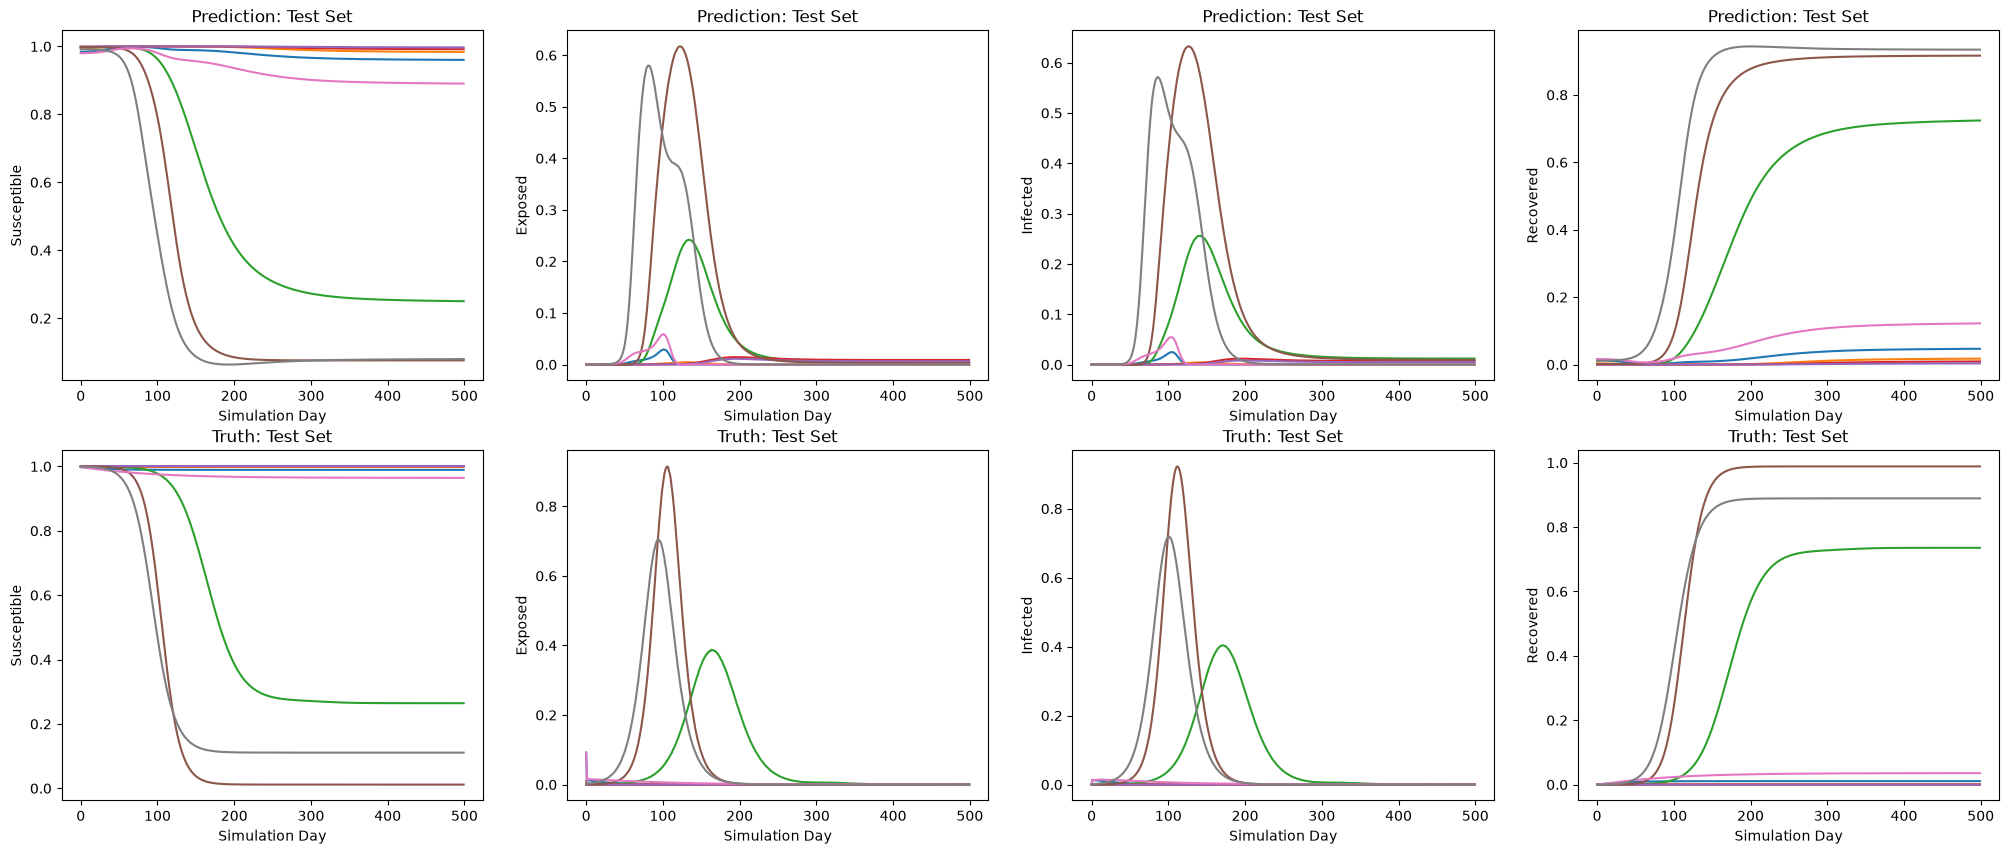

In [12]:
# Evaluate the network on testing data
pred = epi(data_in_test, data_out_test[:,0,:].unsqueeze(1)).cpu().detach().numpy()
truth = data_out_test.cpu().detach().numpy()

# Define figure compartment ID's
compartment_ID = ['Susceptible', 'Exposed', 'Infected', 'Recovered']

# Visualize data in feature vs. time space
plt.figure(figsize=(25,10))
for sim_ind in range(0,len(pred)):
            for ind_compartment in range(0,len(compartment_ID)):
                plt.subplot(2,4,ind_compartment+1)
                plt.plot(pred[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Prediction: Test Set')
    
                plt.subplot(2,4,ind_compartment+len(compartment_ID)+1)
                plt.plot(truth[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Truth: Test Set')

We see that the model does a very reasonable job predicting the test data! There are certainly inaccuracies: the model mis-predicts the magnitude of the peak in the Exposed and Infected columns for certain samples, and there are some small, spurious peaks that appear throughout the system's evolution. But for an intial training effort, the model's generalizability is very promising. More relevant to our application, the model seems to correctly predicts when a pandemic will occur, versus when the system will remain at the equilibrium zero-solution.

The next step of the surrogate modeling process involves refining the model's baseline architecture until inaccurate behavior is eliminated to a level acceptable for your application. Measures for improving the model include tailoring the normalization scheme, incorporating additional constraints into the model architecture (e.g., SEIR compartments should sum to the total population at each time step), and adding additional samples to the train/test sets. One can essentially tweak a surrogate model in perpetuity. The amount of time devoted to refinement depends on the level of accuracy that your application, and the amount of patience that you and your team can muster :)

A quick note on the amount of data in a training set: it is a common adage that more data always results in a better model. This is true to some extent, but I caution the reader against applying it without nuance. For example, if you were to take the 40 samples from this tutorial and augment the dataset with 400 new simulations, your predictions would not necessarily improve. If the new data introduces new dynamical phenomena, you are essentially asking the model to learn a more complex problem, and your individual predictions may in fact get worse (while covering a wider portion of the parameter space). Production surrogate models should be trained on a large number of samples, and "scaling up" is indeed a consistent way to speed up model convergence and introduce flexibility. But take this as a reminder to be careful when curating your training corpus, and ensure that the model is only being asked to learn what is necessary to achieve your design goals.


### Part 5: Ablation Studies

Throughout the previous sections, our effort to build a surrogate model for the SEIR equations proved quite successful, but it's important to remember that there were several design decisions along the way that couldn't be handled rigorously. The model architecture, for example, was informed by the known system dynamics, but in practice, the only way to verify our choice was to train the model on several plausible architectures and refine the best result. The following sections show how the model's predictions change given different normalization schemes, basis functions, and temporal architectures. The goal here is to emphasize the sensitivity of surrogate models to design descisions, and stress that model design often requires many iterations before learning becomes robust. You can think of this section as "learning from our failures."

#### Effect of Data Normalization

Early on in the tutorial, we chose a min/max normalization scheme, normalizing *each feature* independently of the others. This was chosen by the need to separate the data from its scale, and by the "peaky" nature of the data in distribution space. The following example keeps the model architecture and training loop the same, but normalizes all data based on single global maximum, rather than finding a maximum per feature.

In [13]:
# Reload the dataset
data = np.load('/scratch/projects/tacc/sci-training/TACCSTER2026/data/district_of_columbia_dataset.npz')
data_raw_in = torch.tensor(data['data_in'],dtype=torch.float32).to(device)
data_raw_out = torch.tensor(data['data_out'],dtype=torch.float32).to(device)

# Find a global maximum for the entire dataset
max_val = torch.max(data_raw_out)

# Resplit the dataset
test_size = 0.2
data_raw_in_train, data_raw_in_test, data_raw_out_train, data_raw_out_test = train_test_split(data_raw_in/max_val, data_raw_out/max_val, test_size=test_size, random_state=42)

# Initialize a new model object
epi_retrain = EPI(
	hidden_channels=32,
	n_epoch= 10000,
	batch_size=32,
	learning_rate = 1e-2,
	num_total_timesteps=500,
	num_features = 4,
    num_input_parameters = 2,
	basis = basis
	).to(device)

# Retrain the model with slightly different data normalization
epi_retrain.train(data_raw_in_train,data_raw_out_train,data_raw_in_test,data_raw_out_test)

Setting up optimizer...
Starting training...
Epoch: 0  |  Train Loss: 0.1841239184141159  |  Test Loss: 0.18711581826210022
Epoch: 999  |  Train Loss: 0.022696053609251976  |  Test Loss: 0.032227516174316406
Epoch: 1999  |  Train Loss: 0.02234451100230217  |  Test Loss: 0.032864008098840714
Epoch: 2999  |  Train Loss: 0.020404744893312454  |  Test Loss: 0.04039868339896202
Epoch: 3999  |  Train Loss: 0.020082442089915276  |  Test Loss: 0.0396997444331646
Epoch: 4999  |  Train Loss: 0.02001718245446682  |  Test Loss: 0.04026037082076073
Epoch: 5999  |  Train Loss: 0.01998155564069748  |  Test Loss: 0.03822850063443184
Epoch: 6999  |  Train Loss: 0.019867857918143272  |  Test Loss: 0.03923467546701431
Epoch: 7999  |  Train Loss: 0.020033178851008415  |  Test Loss: 0.0389089435338974
Epoch: 8999  |  Train Loss: 0.0204207394272089  |  Test Loss: 0.0424313023686409
Epoch: 9999  |  Train Loss: 0.019783852621912956  |  Test Loss: 0.040509045124053955


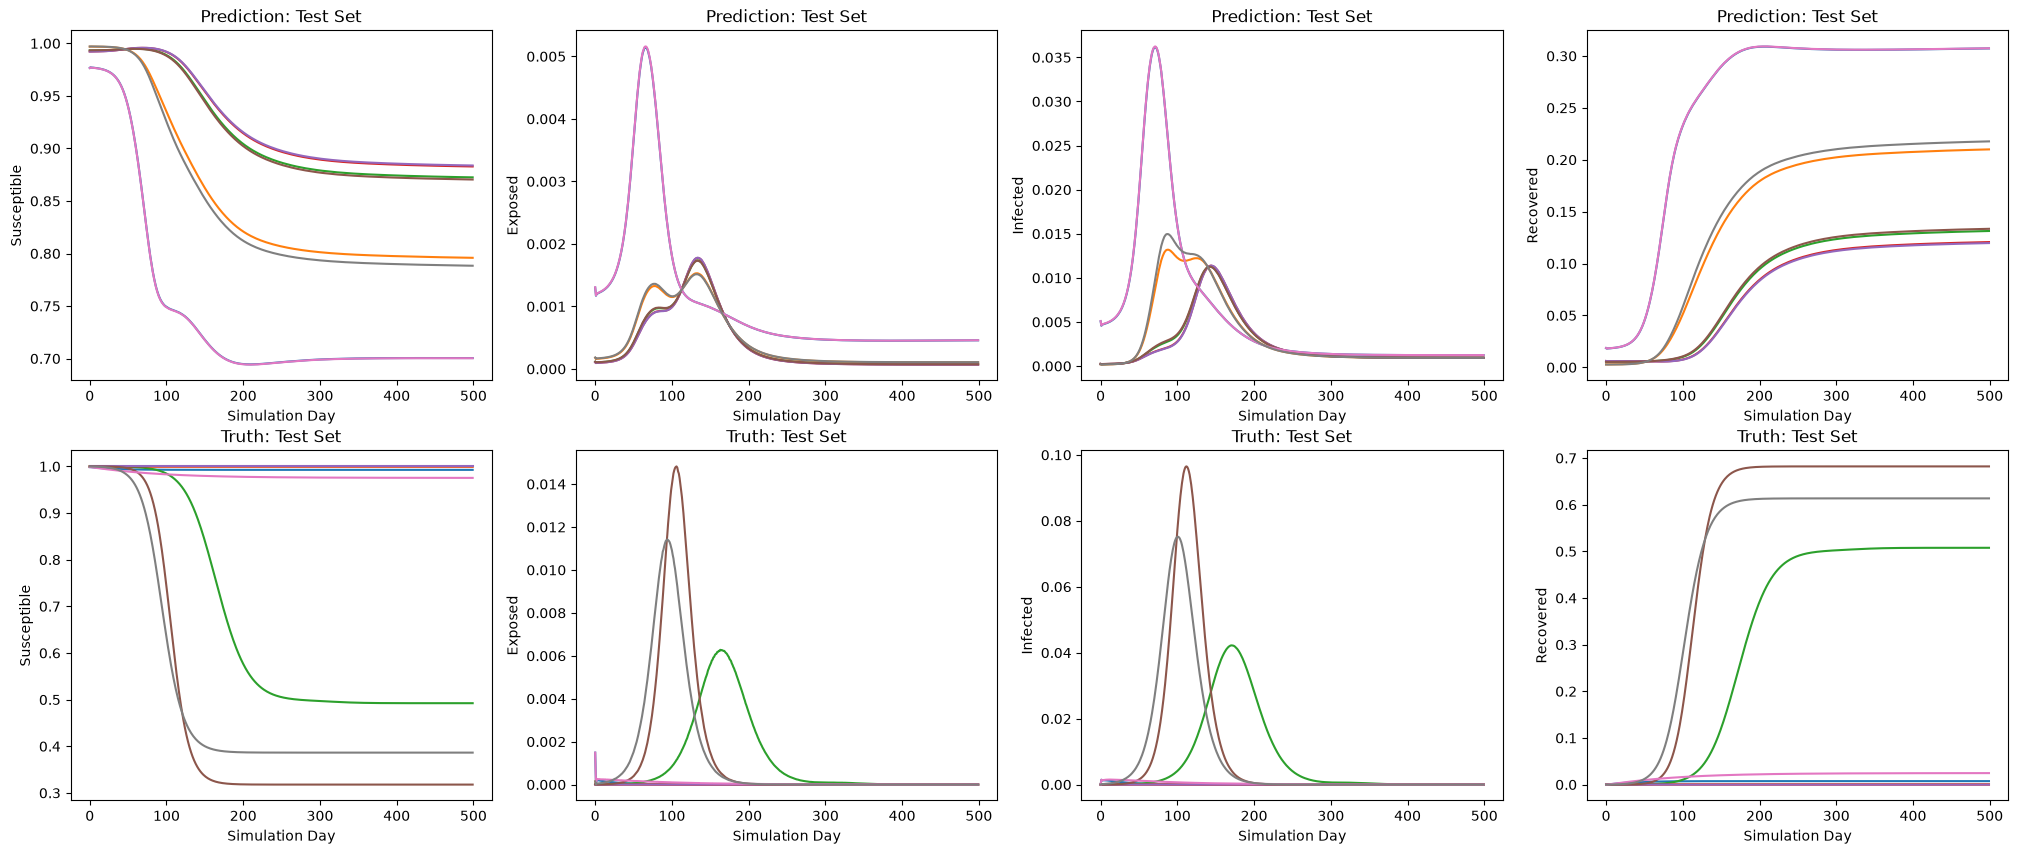

In [14]:
# Evaluate the network on testing data
pred = epi_retrain(data_raw_in_test, data_raw_out_test[:,0,:].unsqueeze(1)).cpu().detach().numpy()
truth = (data_raw_out_test).cpu().detach().numpy()

# Define figure compartment ID's
compartment_ID = ['Susceptible', 'Exposed', 'Infected', 'Recovered']

# Visualize data in feature vs. time space
plt.figure(figsize=(25,10))
for sim_ind in range(0,len(pred)):
            for ind_compartment in range(0,len(compartment_ID)):
                plt.subplot(2,4,ind_compartment+1)
                plt.plot(pred[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Prediction: Test Set')
    
                plt.subplot(2,4,ind_compartment+len(compartment_ID)+1)
                plt.plot(truth[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Truth: Test Set')

We see that this slight change results in substantially less accurate predictions on the test set. The reason for this can be traced back to the nature of SEIR data: the susceptible compartment always monotonically decreases from the total population, while the other three compartments are initialized to low values and gradually increase. As an illustration, the distribution plot of Part 1 shows that the suscetible compartment is skewed heavily to larger values, while the remaining three compartments are skewed heavily to zero. The magnitude difference means the model implicitly prioritizes a single feature during training, making it difficult to learn the complete system.

Note that while writing this tutorial, we also tested the same model architecture with a Z-score normalization, subtracting the mean and dividing by the standard deviation for each feature. This proved to be ill-suited to our dataset, a result of its "peaky" distribution. The model converged to a local minima with even worse overall accuracy than what was seen above.

#### Effect of Basis Function Smoothing

During the design of our model architecture, we made the choice to incorporate a small, finite number of basis functions, mapping simulation inputs to PCA coefficients, rather than mapping directly to the output space. We mentioned that this choice was driven by the knowledge that we expect our outputs to be continuous in time. This is very much true, but it's important to pinpoint exactly how the basis functions improve our predictions. We will do this by retraining the model without a set of smooth basis functions. We won't go too far into the theory of PCA, but know that this task is equivalent to using an infinite number of basis functions. In the cells below, we retrain the model on a substantially larger number of PCA modes:

In [15]:
# Extract tailored basis from PCA
numPCA = int(160)
pca = PCA(n_components=numPCA, svd_solver='auto')
X = np.permute_dims(data_out.cpu(), axes=(0,2,1))
X = X.reshape(-1, *X.shape[2:])
pca.fit(X)
basis = pca.components_[0:numPCA]
basis = torch.tensor(basis,dtype=torch.float32)
basis = basis.to(device)

# Initialize model architecture
print('Initializing model...')
epi_retrain = EPI(
	hidden_channels=64,
	n_epoch= 10000,
	batch_size=32,
	learning_rate = 1e-3,
	num_total_timesteps=500,
	num_features = 4,
    num_input_parameters = 2,
	basis = basis
	).to(device)

epi_retrain.train(data_in_train,data_out_train,data_in_test,data_out_test)

Initializing model...
Setting up optimizer...
Starting training...
Epoch: 0  |  Train Loss: 0.25996142625808716  |  Test Loss: 0.27544713020324707
Epoch: 999  |  Train Loss: 0.015482851304113865  |  Test Loss: 0.020922742784023285
Epoch: 1999  |  Train Loss: 0.011647483333945274  |  Test Loss: 0.011918480508029461
Epoch: 2999  |  Train Loss: 0.010378478094935417  |  Test Loss: 0.010519009083509445
Epoch: 3999  |  Train Loss: 0.00920196808874607  |  Test Loss: 0.009855479001998901
Epoch: 4999  |  Train Loss: 0.008680996485054493  |  Test Loss: 0.010155368596315384
Epoch: 5999  |  Train Loss: 0.007120518945157528  |  Test Loss: 0.009001816622912884
Epoch: 6999  |  Train Loss: 0.004873794037848711  |  Test Loss: 0.006412679795175791
Epoch: 7999  |  Train Loss: 0.0021241670474410057  |  Test Loss: 0.0032329093664884567
Epoch: 8999  |  Train Loss: 0.0017507408047094941  |  Test Loss: 0.003051378298550844
Epoch: 9999  |  Train Loss: 0.0014902993571013212  |  Test Loss: 0.002843172987923026


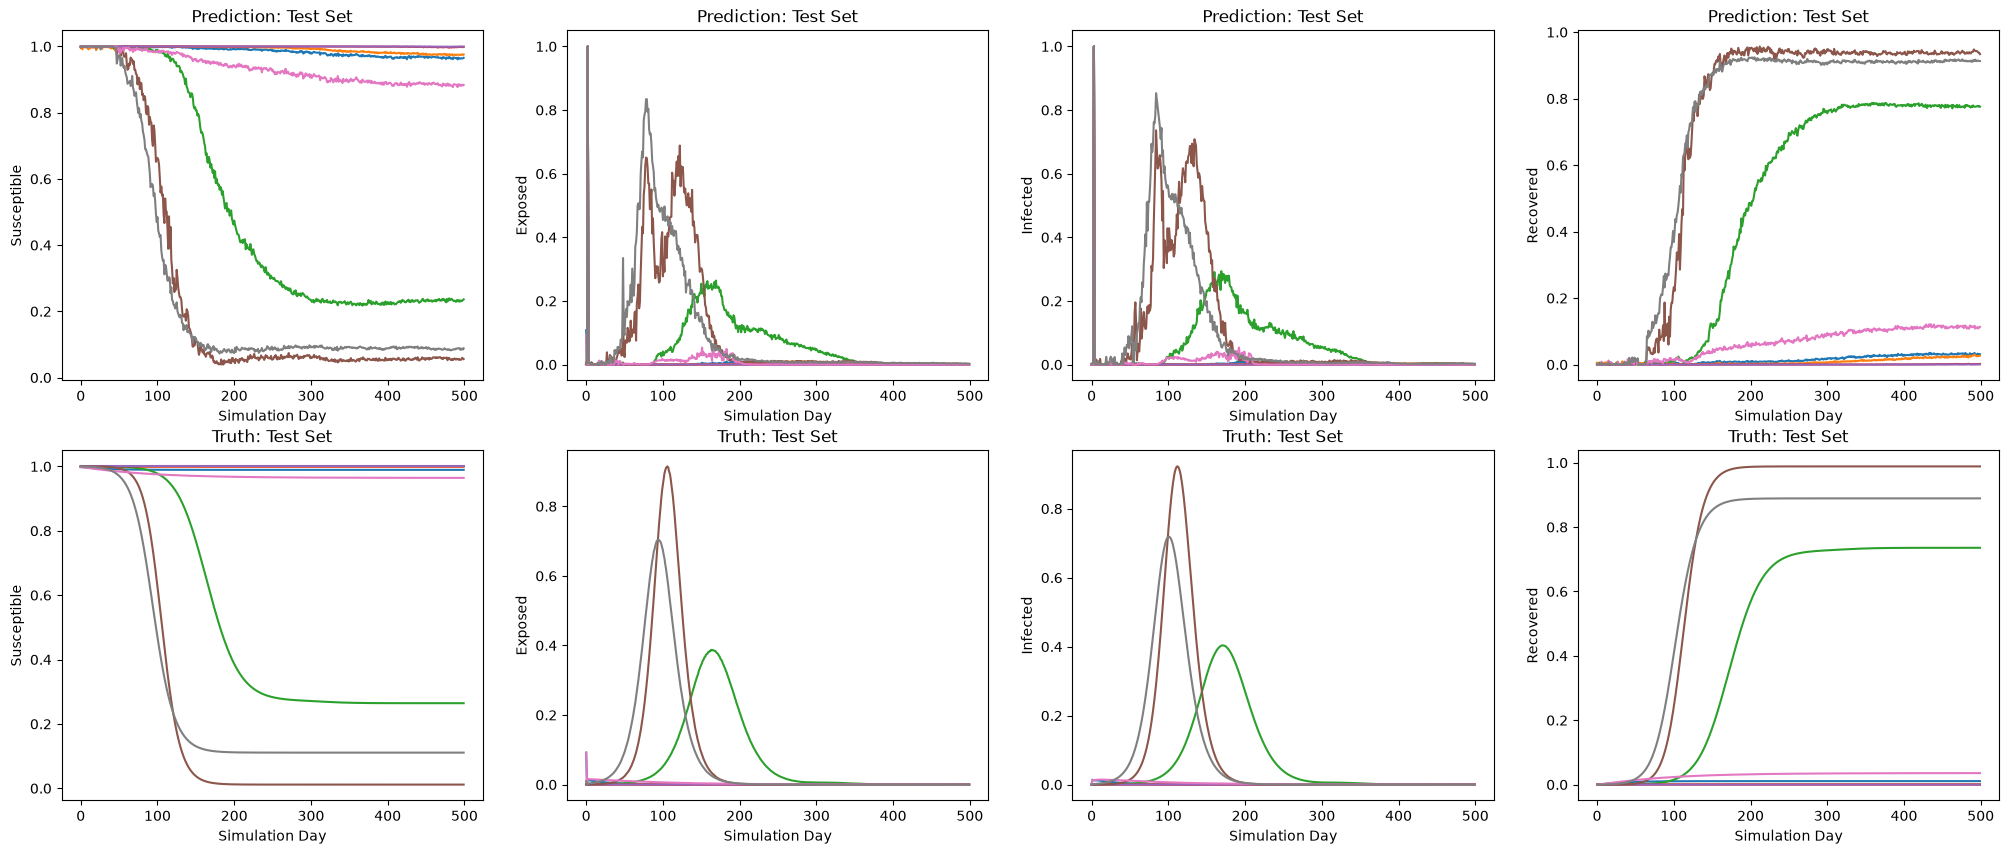

In [16]:
# Evaluate the network on testing data
pred = epi_retrain(data_in_test, data_out_test[:,0,:].unsqueeze(1)).cpu().detach().numpy()
truth = (data_out_test).cpu().detach().numpy()

# Define figure compartment ID's
compartment_ID = ['Susceptible', 'Exposed', 'Infected', 'Recovered']

# Visualize data in feature vs. time space
plt.figure(figsize=(25,10))
for sim_ind in range(0,len(pred)):
            for ind_compartment in range(0,len(compartment_ID)):
                plt.subplot(2,4,ind_compartment+1)
                plt.plot(pred[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Prediction: Test Set')
    
                plt.subplot(2,4,ind_compartment+len(compartment_ID)+1)
                plt.plot(truth[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Truth: Test Set')

Note that the model still learned a good bit about the dataset, correctly predicting which initial conditions lead to a pandemic, and correctly tracing the rough shape of each compartment's evolution. The output, however, is quite noisy over time! This is because without limiting the space of solution functions, the model does not "know" that the solution should be continuous in time. The model is effectively predicting each time point independently; in this sense, incorporating a small number of basis function is a way to tell the model that the output is correlated in the time dimension. This result speaks to the importance of configuring the model architecture to your system: if you know the system should be continuous in time, it will dramatically speed up convergence to incorporate continuity as a hard constraint in your architecture.

#### Trajectory Maps Versus Time-Steppers

Perhaps the most impactful design decision in surrogate modeling is the choice between trajectory maps and flow maps (i.e., time-steppers). This is fundamentally a tradeoff between dimensionality and stability. Trajectory maps are inherently stable in the time dimension, while suffering from high dimensionality. Flow maps substantially reduce the dimension of the problem but suffer from instability and error accumulation. The appropriate choice ultimately comes down to which of these limitations is easier to overcome for your specific system.

That being said, it's often worthwhile to try a baseline version of both to see which is a better fit to your system dynamics. The following cells implement a flow map architecture for the compartment model problem, configuring the network to output the solution one step at a time. To properly implmement a flow map, we'll need to redesign several aspects of our network architecure, namely:

- Re-writing the feedforward function such that it operates per time step, rather than per trajectory
- Re-write the training loop such that it steps through successive timesteps and adds each single step prediction to the loss

Let's see what this looks like!

In [17]:
class EPI_single_step(torch.nn.Module):

    # Initialization
    def __init__(  
        self,
        hidden_channels: int,      # The 'width' or 'capacity' of the network
        num_total_timesteps: int,  # The total number of timesteps in the output trajectory
        num_features: int,         # The number of features in our state vector
        n_epoch: int,              # Training parameter: number of iterations or epochs
        batch_size: int,           # Training parameter: the number of samples per batch
        learning_rate: float,      # Training parameter: the initial learning rate
        ):
        super().__init__()

        # The following lines are a PyTorch quirk, we store the input parameters as class constants so they 
        # can be called within the training method
        self.hidden_channels = hidden_channels
        self.num_total_timesteps = num_total_timesteps
        self.num_features = num_features
        self.activation = nn.ReLU()
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.n_epoch = n_epoch

        # Define each layer of the feedforward architecture
        self.layer1 = nn.Linear(self.num_features,self.hidden_channels)
        self.layer2 = nn.Linear(self.hidden_channels,self.hidden_channels)
        self.layer3 = nn.Linear(self.hidden_channels,self.hidden_channels)
        self.output_head = nn.Linear(self.hidden_channels,self.num_features)

        # Define the loss function
        self.loss = nn.MSELoss()

    # Forward pass function
    def forward(self, xin):

        # Extract current batch size
        batch_size = xin.shape[0]

        # Feedforward from the input
        x = self.layer1(xin)
        x = self.activation(x)
        x = self.layer2(x)
        x = self.activation(x)
        x = self.layer3(x)
        x = self.activation(x)
        dx = self.output_head(x)

        # Map forward one time step
        xout = xin+dx
        
        return xout    

    def train(self, data_in, data_out):

        print('Setting up optimizer...')
        optimizer = optim.Adam([
            {'params': self.layer1.parameters()},
            {'params': self.layer2.parameters()},
            {'params': self.layer3.parameters()},
            {'params': self.output_head.parameters()},
            ],lr = self.learning_rate)

        print('Starting training...')
        for it in range(0, self.n_epoch):

            ind_shuffle = torch.randperm(data_in.size()[0])
            data_in = data_in[ind_shuffle]
            data_out = data_out[ind_shuffle]
            loss_track = 0.0

            start_time = time.perf_counter()

            for ind in range(0,data_in.size()[0],self.batch_size):
                loss = 0.0
                optimizer.zero_grad()
                ind_batch = range(ind,ind+self.batch_size)

                if ind+self.batch_size > data_in.size()[0]:
                    ind_batch = range(ind,data_in.size()[0])
                loss = 0.
                for ind_time in range(1,self.num_total_timesteps):
                    xin = data_out[ind_batch,ind_time-1,:]
                    data_pred = self(xin.unsqueeze(1))
                    loss += self.loss(data_pred,data_out[ind_batch,ind_time,:].unsqueeze(1))  
                    
                loss.backward()
                optimizer.step()
                loss_track += float(loss.item())
            end_time = time.perf_counter()

            if it == 0 or (it+1)%10==0:
                print('Epoch: ' + str(it) + '  |  ' + 'Train Loss: ' + str(loss_track))

In [18]:
# Initialize model architecture
print('Initializing model...')
epi_single_step = EPI_single_step(
	hidden_channels=64,
	n_epoch= 100,
	batch_size=32,
	learning_rate = 1e-3,
	num_total_timesteps=500,
	num_features = 4,
	).to(device)

epi_single_step.train(data_in_train,data_out_train)

Initializing model...
Setting up optimizer...
Starting training...
Epoch: 0  |  Train Loss: 4.160327434539795
Epoch: 9  |  Train Loss: 0.08052300661802292
Epoch: 19  |  Train Loss: 0.06201677396893501
Epoch: 29  |  Train Loss: 0.04351748526096344
Epoch: 39  |  Train Loss: 0.01165773905813694
Epoch: 49  |  Train Loss: 0.009508192539215088
Epoch: 59  |  Train Loss: 0.005929930135607719
Epoch: 69  |  Train Loss: 0.003833416849374771
Epoch: 79  |  Train Loss: 0.002935186494141817
Epoch: 89  |  Train Loss: 0.002424767706543207
Epoch: 99  |  Train Loss: 0.0020132260397076607


Note that compared to a full trajectory map, the loss converges within a much smaller number of epochs! Because the network predicts one time step at a time, it treats every individual timestep as a sample. We have effectively increased the number of samples that the time-stepper sees (40 trajectories * 500 steps each), compared to our full trajectory maps (40 trajectories).

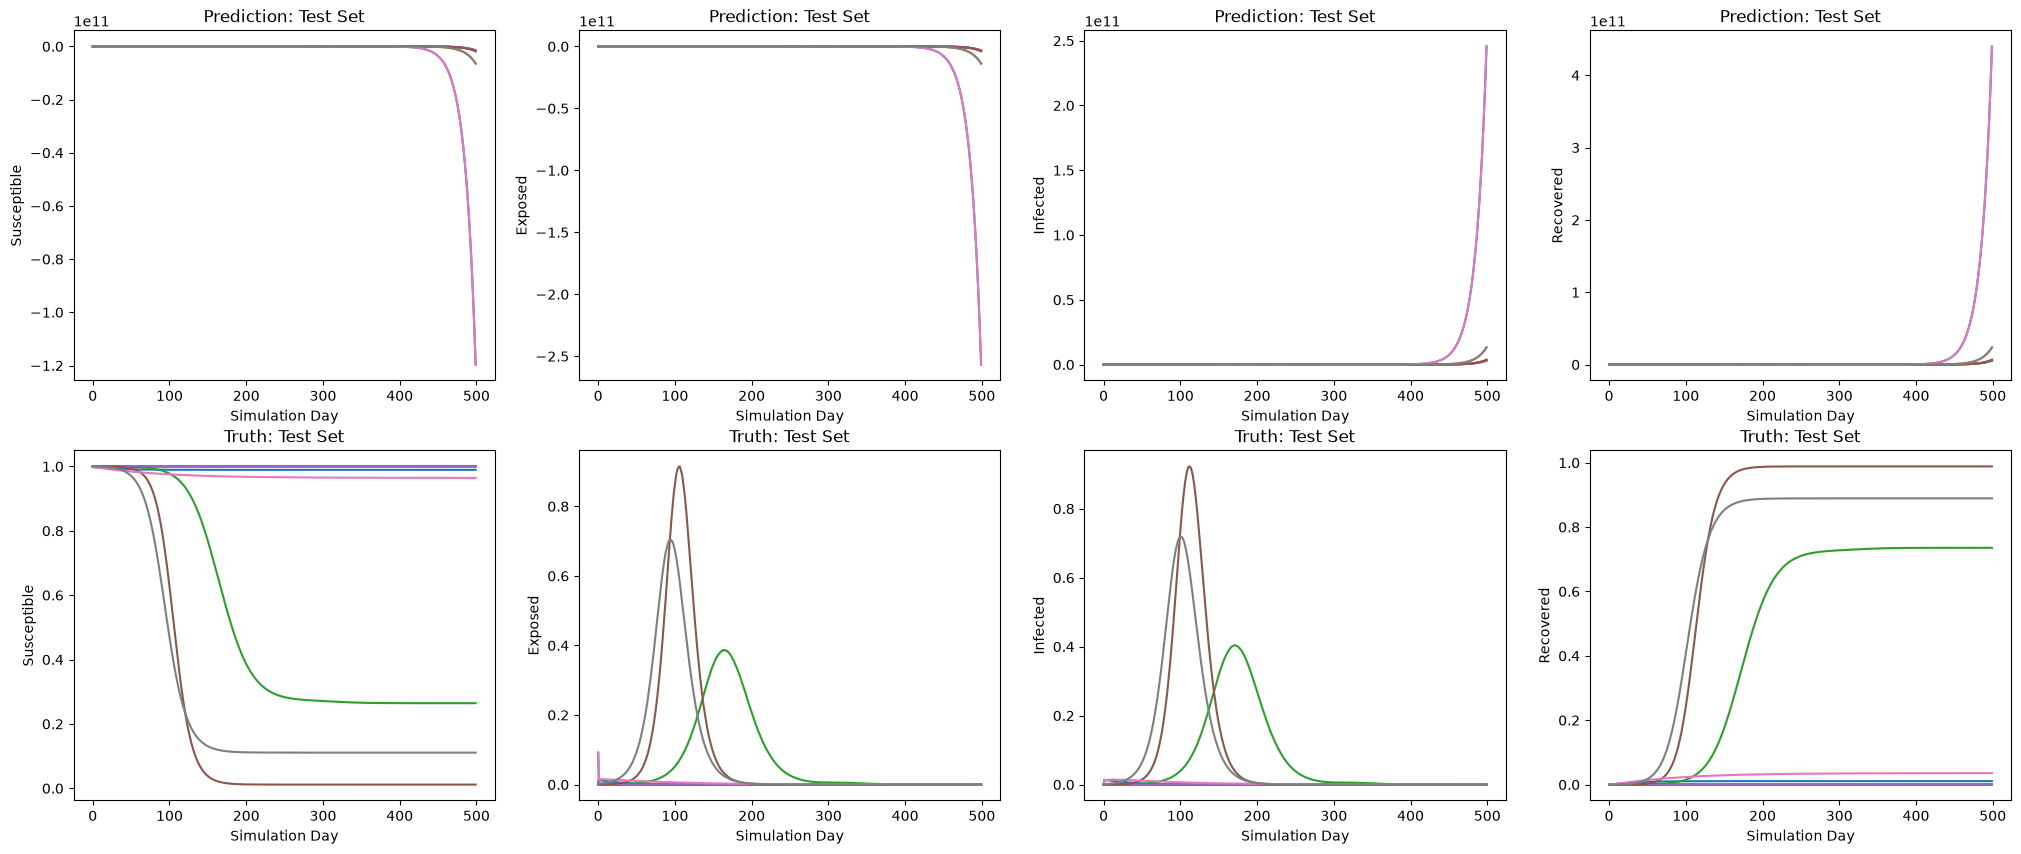

In [19]:
data_pred = torch.zeros_like(data_out_test).to(device)
xin = data_out_test[:,0,:].unsqueeze(1)
data_pred[:,0,:] = data_out_test[:,0,:]
for ind_time in range(1,500):
    data_pred[:,ind_time,:] = epi_single_step(xin).squeeze()
    xin = data_pred[:,ind_time,:]

pred = data_pred.cpu().detach().numpy()
truth = data_out_test.cpu().detach().numpy()

# Define figure compartment ID's
compartment_ID = ['Susceptible', 'Exposed', 'Infected', 'Recovered']

# Visualize data in feature vs. time space
plt.figure(figsize=(25,10))
for sim_ind in range(0,len(pred)):
            for ind_compartment in range(0,len(compartment_ID)):
                plt.subplot(2,4,ind_compartment+1)
                plt.plot(pred[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Prediction: Test Set')
    
                plt.subplot(2,4,ind_compartment+len(compartment_ID)+1)
                plt.plot(truth[sim_ind,:,ind_compartment])
                plt.xlabel('Simulation Day')
                plt.ylabel(compartment_ID[ind_compartment])
                plt.title('Truth: Test Set')


What a bizarre result! Notice that the predictions diverge massively, spiking more than 10 orders of magnitude as the model rolls out over successive time steps. This is the classic signature of runaway error accumulation that haunts time-stepping methods, both in surrogate modeling and conventional CPU-cluster computing. The model is accurate on a per-timestep basis, but those inaccuracies are unbounded over successive predictions. This is similar to the "context rot" problem seen in large language models.

There are several potential solutions to stability issues like this. Perhaps the most obvious is to rollout the model over several timesteps during training, such that the model can learn from its errors. However, this approach inroduces unstable rollouts into the training procedure, complicating the optimization space and dramatically slowing convergence. 

Hybrid methods represent a slightly more realistic approach. The hybrid approach combines flow maps and trajectory maps: the model predicts $n$ steps at once, where $n$ is less than the total number of timesteps in the trajectory. This has the effect of minimzing the number of model evaluations per trajectory (and thus minimizing the potential for error accumulation) while reaping the benefits of dimensionality reduction inherent to flow maps. Still, stability issues will be a persistent with any form of the time-stepper approach, and finding general ways to stabilize surrogate system is very much an active and ongoing area of research.